# Taller 9: Redes Neuronales Convolucionales con Modelos Fundacionales

### Sebastián Palma

In [50]:
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd
import os
import cv2
import json
import time
from tensorflow import keras
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  GlobalAveragePooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import f1_score
from tensorflow.keras.models import load_model
from sklearn.metrics import f1_score, precision_score, recall_score
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import Model
from tensorflow.keras.applications import MobileNetV2

## 1. Descarga y Preparación del Dataset de Kaggle

In [3]:
from kaggle.api.kaggle_api_extended import KaggleApi

with open('./kaggle.json') as f:
    kaggle_credentials = json.load(f)

os.environ['KAGGLE_USERNAME'] = kaggle_credentials['username']
os.environ['KAGGLE_KEY'] = kaggle_credentials['key']

api = KaggleApi()
api.authenticate()
api.dataset_download_files('shreyapmaher/fruits-dataset-images', path='data', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/shreyapmaher/fruits-dataset-images


## 2. Exploracion de Datos

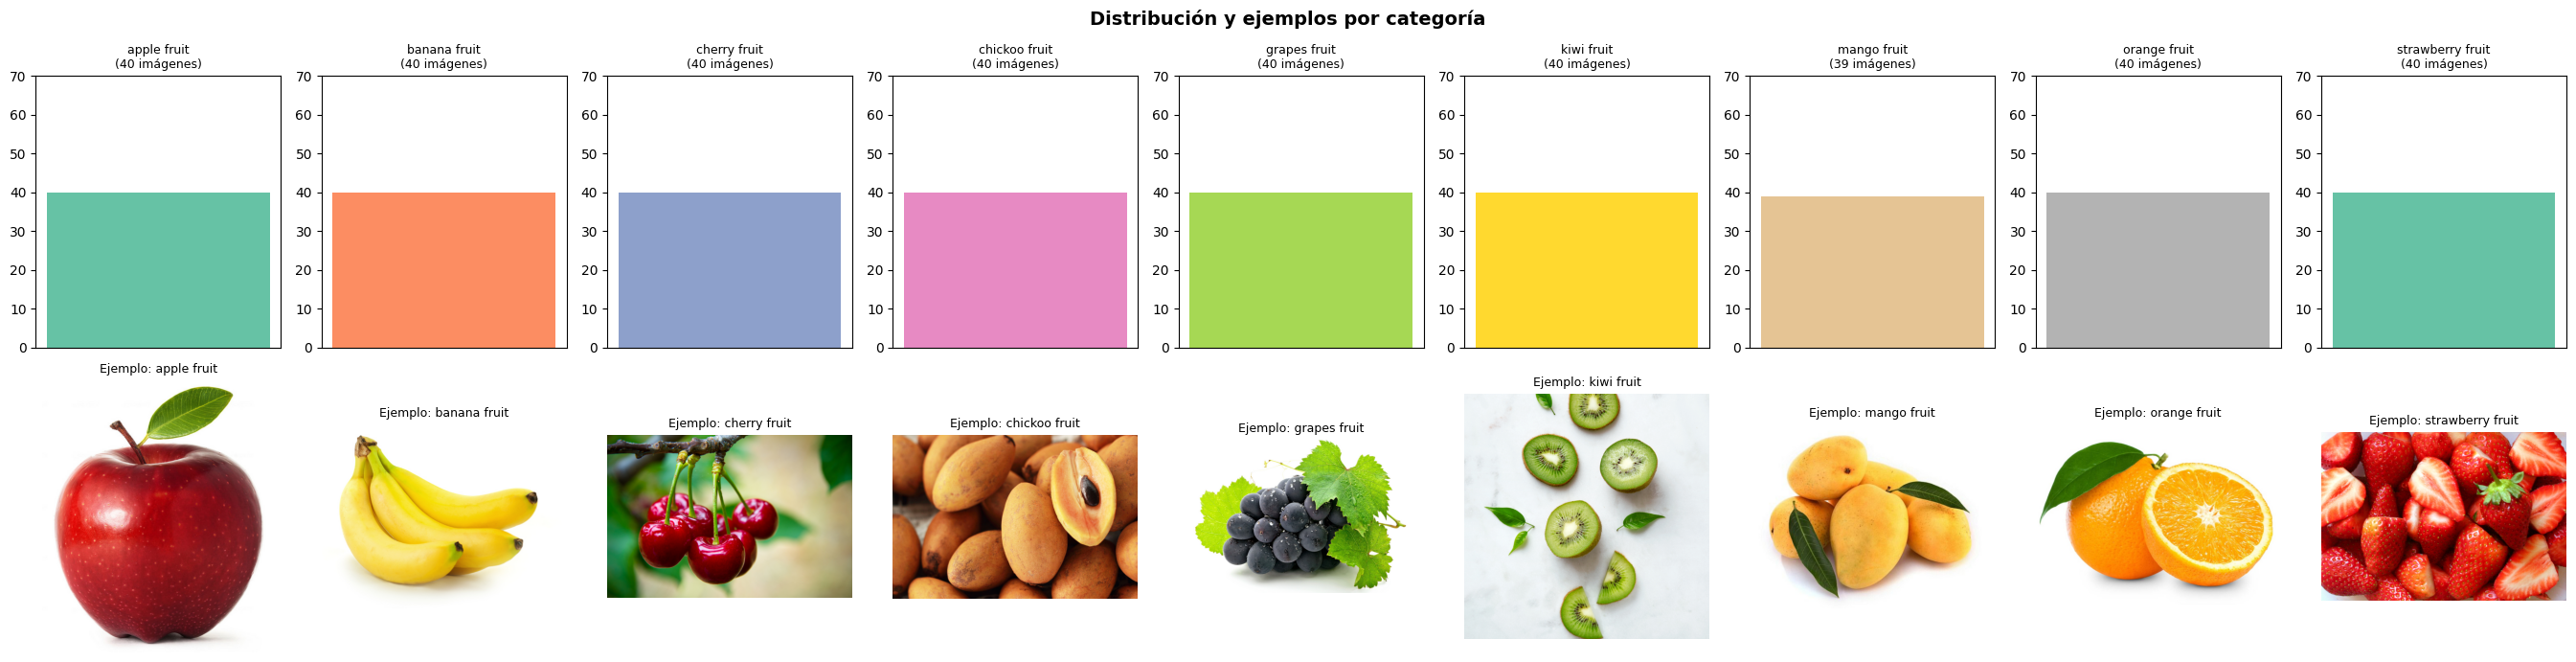

In [13]:
base_dir = Path('data/images')

filepaths, labels = [], []
for label_folder in sorted(base_dir.iterdir()):
    if label_folder.is_dir():
        for file in label_folder.iterdir():
            if file.suffix.lower() in ['.png', '.jpg', '.jpeg']:
                filepaths.append(str(file))
                labels.append(label_folder.name)

data_df = pd.DataFrame({'filepath': filepaths, 'label': labels})
categorias = sorted(data_df['label'].unique())
num_cats = len(categorias)
colors = plt.cm.Set2.colors  
fig, axes = plt.subplots(2, num_cats, figsize=(num_cats * 3, 7))
conteos = data_df['label'].value_counts()
max_count = conteos.max()

for i, cat in enumerate(categorias):
    axes[0, i].bar([cat], [conteos[cat]], color=colors[i % len(colors)])
    axes[0, i].set_title(f"{cat}\n({conteos[cat]} imágenes)", fontsize=9)
    axes[0, i].set_ylim(0, max_count + 30)
    axes[0, i].set_xticks([])

    ejemplo = data_df[data_df['label'] == cat].iloc[0]['filepath']
    img = mpimg.imread(ejemplo)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Ejemplo: {cat}", fontsize=9)
    axes[1, i].axis('off')

plt.suptitle("Distribución y ejemplos por categoría", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Preprocesamiento de Datos

In [14]:
train_df, test_val_df = train_test_split(
    data_df, test_size=0.3, random_state=42, stratify=data_df['label']
)

val_df, test_df = train_test_split(
    test_val_df, test_size=(1/3), random_state=42, stratify=test_val_df['label']
)

print("Entrenamiento:", len(train_df))
print("Validación:   ", len(val_df))
print("Prueba:       ", len(test_df))

Entrenamiento: 251
Validación:    72
Prueba:        36


## 4. Generadores de Imágenes

In [ ]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

idx_to_class = {v: k for k, v in train_gen.class_indices.items()}
class_names  = [idx_to_class[i] for i in sorted(idx_to_class)]
num_classes  = len(class_names)
y_true       = test_gen.classes 

print('\nCategorías reconocidas:')
for idx, name in enumerate(class_names):
    print(f"  Clase {idx}: '{name}'")
print('Número de clases:', num_classes)

Found 251 validated image filenames belonging to 9 classes.
Found 72 validated image filenames belonging to 9 classes.
Found 36 validated image filenames belonging to 9 classes.

Categorías reconocidas:
  Clase 0: 'apple fruit'
  Clase 1: 'banana fruit'
  Clase 2: 'cherry fruit'
  Clase 3: 'chickoo fruit'
  Clase 4: 'grapes fruit'
  Clase 5: 'kiwi fruit'
  Clase 6: 'mango fruit'
  Clase 7: 'orange fruit'
  Clase 8: 'strawberry fruit'
Número de clases: 9


## 5. Experimentación con Modelos Fundacionales Adicionales

### 5.1. Modelo 1: MobileNetV2

### 5.1.1. Construcción del modelo

In [17]:
base_mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

for layer in base_mobilenet.layers:
    layer.trainable = False

model_mobilenet = Sequential([
    base_mobilenet,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),             
    Dense(num_classes, activation='softmax')
])

model_mobilenet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_mobilenet.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,113 (9.24 MB)

 Trainable params: 165,129 (645.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 5.1.2. Entrenamiento

In [20]:
callbacks_mobilenet = [
    ModelCheckpoint('best_model_mobilenet.keras', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5,verbose=1, mode='min')
]

start_mobilenet = time.time()

with tf.device('/device:GPU:0'):
    history_mobilenet = model_mobilenet.fit(
        train_gen,
        validation_data=val_gen,
        epochs=15,
        callbacks=callbacks_mobilenet
    )

time_mobilenet = round(time.time() - start_mobilenet, 2)
print(f"\nTiempo de entrenamiento MobileNetV2: {time_mobilenet}s")

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.1275 - loss: 2.6072 - val_accuracy: 0.1389 - val_loss: 2.2123 - learning_rate: 1.0000e-04
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 784ms/step - accuracy: 0.2390 - loss: 2.1617 - val_accuracy: 0.2083 - val_loss: 1.9326 - learning_rate: 1.0000e-04
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 796ms/step - accuracy: 0.3426 - loss: 1.8396 - val_accuracy: 0.4167 - val_loss: 1.7106 - learning_rate: 1.0000e-04
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 846ms/step - accuracy: 0.3625 - loss: 1.7281 - val_accuracy: 0.5000 - val_loss: 1.5305 - learning_rate: 1.0000e-04
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 823ms/step - accuracy: 0.4940 - loss: 1.4402 - val_accuracy: 0.6389 - val_loss: 1.3763 - learning_rate: 1.0000e-04
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 867ms/step - accuracy: 0.5259 - loss: 1.4086 - val_accuracy: 0.6806 - val_loss: 1.2457 - learning_rate: 1.0000e-04
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 895ms/step - accuracy: 0.6135 - loss: 1

### 5.1.3. Evaluación

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 720ms/step


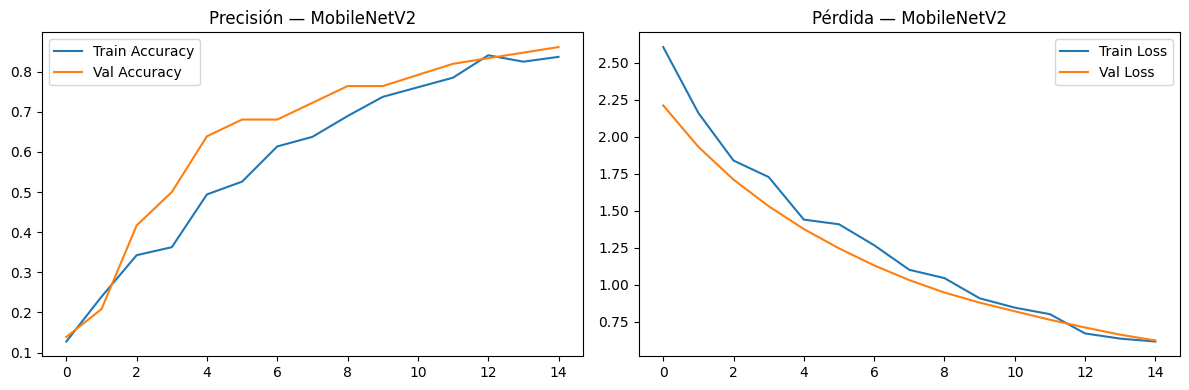

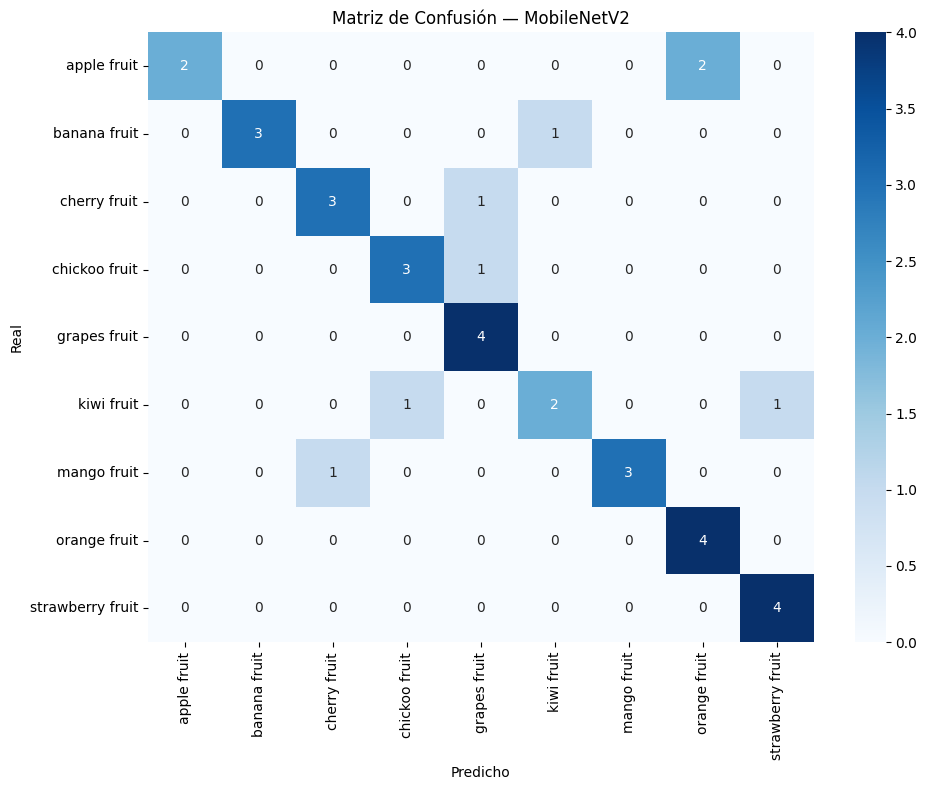

Reporte de Clasificacion — MobileNetV2
                  precision    recall  f1-score   support

     apple fruit       1.00      0.50      0.67         4
    banana fruit       1.00      0.75      0.86         4
    cherry fruit       0.75      0.75      0.75         4
   chickoo fruit       0.75      0.75      0.75         4
    grapes fruit       0.67      1.00      0.80         4
      kiwi fruit       0.67      0.50      0.57         4
     mango fruit       1.00      0.75      0.86         4
    orange fruit       0.67      1.00      0.80         4
strawberry fruit       0.80      1.00      0.89         4

        accuracy                           0.78        36
       macro avg       0.81      0.78      0.77        36
    weighted avg       0.81      0.78      0.77        36


Accuracy en test: 0.7778
Épocas entrenadas: 15
Tiempo total: 105.19s


In [ ]:
best_mobilenet = load_model('best_model_mobilenet.keras')
test_gen.reset()
preds_mobilenet  = best_mobilenet.predict(test_gen, verbose=1)
y_pred_mobilenet = np.argmax(preds_mobilenet, axis=1)

# Curvas de entrenamiento
acc_m = history_mobilenet.history['accuracy']
val_acc_m  = history_mobilenet.history['val_accuracy']
loss_m = history_mobilenet.history['loss']
val_loss_m = history_mobilenet.history['val_loss']
epochs_r = range(len(acc_m))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_r, acc_m,     label='Train Accuracy')
plt.plot(epochs_r, val_acc_m, label='Val Accuracy')
plt.legend(); plt.title('Precisión — MobileNetV2')
plt.subplot(1, 2, 2)
plt.plot(epochs_r, loss_m,     label='Train Loss')
plt.plot(epochs_r, val_loss_m, label='Val Loss')
plt.legend(); plt.title('Pérdida — MobileNetV2')
plt.tight_layout(); plt.show()

# Matriz de confusion
cm_m = confusion_matrix(y_true, y_pred_mobilenet)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusion — MobileNetV2')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.tight_layout(); plt.show()

# Reporte de clasificacion
print("Reporte de Clasificacion — MobileNetV2")
print(classification_report(y_true, y_pred_mobilenet, target_names=class_names, zero_division=0))

# Guardar metricas 
acc_test_mobilenet = best_mobilenet.evaluate(test_gen, verbose=0)[1]
epochs_mobilenet   = len(acc_m)
print(f"\nAccuracy en test: {acc_test_mobilenet:.4f}")
print(f"Épocas entrenadas: {epochs_mobilenet}")
print(f"Tiempo total: {time_mobilenet}s")

### 5.2. Modelo 2: EfficientNetB0

### 5.2.0. Generadores de Imágenes

In [42]:
IMG_SIZE_INCEPTION = (150, 150)

train_datagen_inception = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)
val_test_datagen_inception = ImageDataGenerator(rescale=1./255)

train_gen_inception = train_datagen_inception.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE_INCEPTION, batch_size=BATCH_SIZE,
    class_mode='categorical'
)
val_gen_inception = val_test_datagen_inception.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE_INCEPTION, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_gen_inception = val_test_datagen_inception.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE_INCEPTION, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

y_true_inception = test_gen_inception.classes

Found 251 validated image filenames belonging to 9 classes.
Found 72 validated image filenames belonging to 9 classes.
Found 36 validated image filenames belonging to 9 classes.


### 5.2.1. Construcción del modelo

In [51]:
base_inception = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

# Congelamos todas las capas base
for layer in base_inception.layers:
    layer.trainable = False

model_inception = Sequential([
    base_inception,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'), 
    Dropout(0.3),                 
    Dense(num_classes, activation='softmax')
])

# Hiperparámetro 3: learning rate 1e-4
model_inception.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_inception.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 3, 3, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,329,641 (85.18 MB)

 Trainable params: 526,857 (2.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

### 5.2.2. Entrenamiento

In [52]:
callbacks_inception = [
    ModelCheckpoint('best_model_inception.keras', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')
]

start_inception = time.time()

with tf.device('/device:GPU:0'):
    history_inception = model_inception.fit(
        train_gen_inception,
        validation_data=val_gen_inception,
        epochs=15,
        callbacks=callbacks_inception
    )

time_inception = round(time.time() - start_inception, 2)
print(f"\nTiempo de entrenamiento InceptionV3: {time_inception}s")

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.1235 - loss: 3.2864 - val_accuracy: 0.3333 - val_loss: 1.9539 - learning_rate: 1.0000e-04
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.3466 - loss: 1.9742 - val_accuracy: 0.5556 - val_loss: 1.3910 - learning_rate: 1.0000e-04
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5100 - loss: 1.5673 - val_accuracy: 0.6250 - val_loss: 1.0950 - learning_rate: 1.0000e-04
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6375 - loss: 1.1424 - val_accuracy: 0.6944 - val_loss: 0.8769 - learning_rate: 1.0000e-04
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7012 - loss: 0.9987 - val_accuracy: 0.7778 - val_loss: 0.7741 - learning_rate: 1.0000e-04
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7809 - loss: 0.7094 - val_accuracy: 0.7639 - val_loss: 0.7051 - learning_rate: 1.0000e-04
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7530 - loss: 0.7612 - val_accur

### 5.2.3. Evaluación

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step


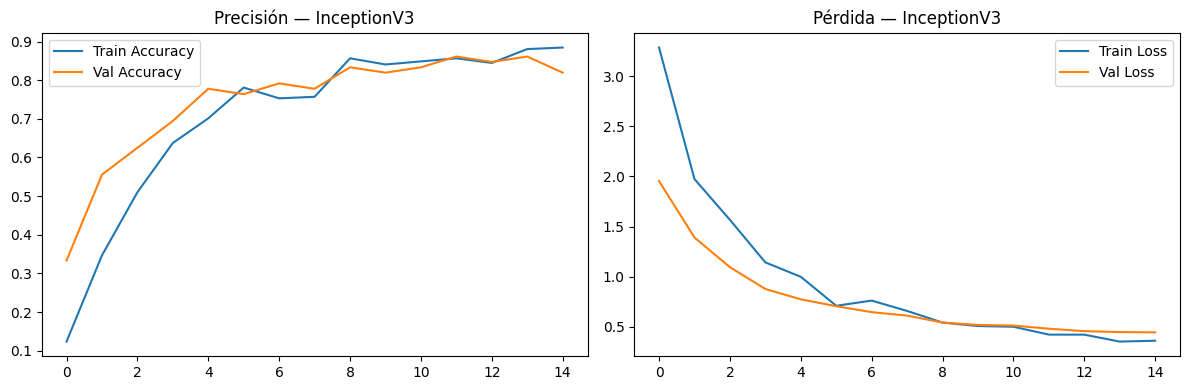

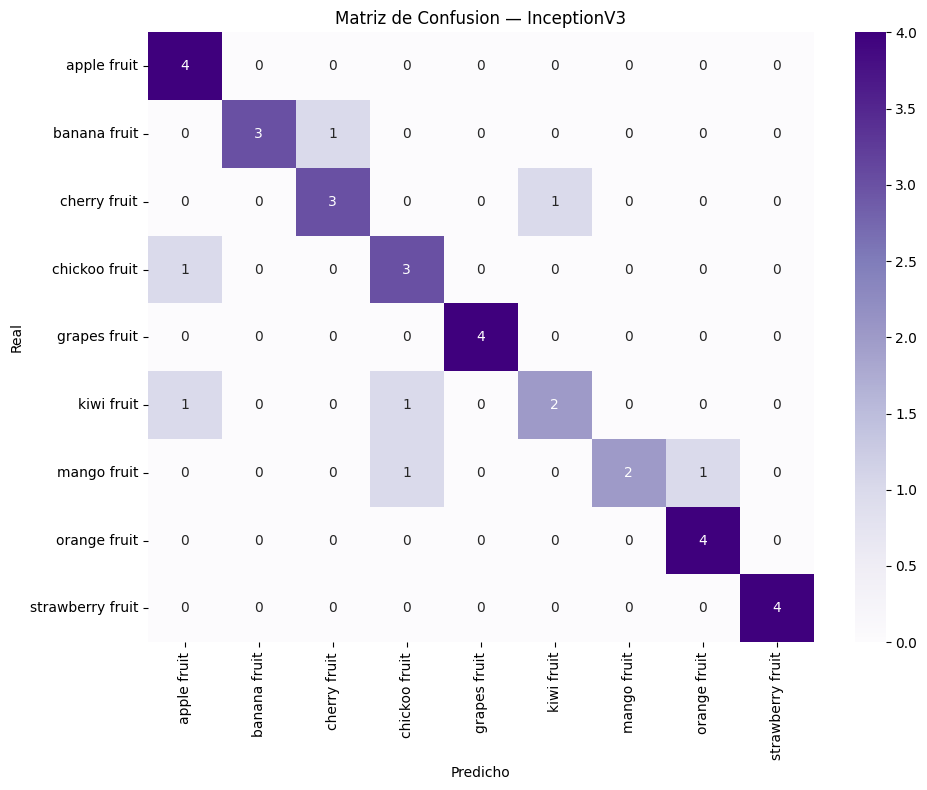

Reporte de Clasificacion — InceptionV3
                  precision    recall  f1-score   support

     apple fruit       0.67      1.00      0.80         4
    banana fruit       1.00      0.75      0.86         4
    cherry fruit       0.75      0.75      0.75         4
   chickoo fruit       0.60      0.75      0.67         4
    grapes fruit       1.00      1.00      1.00         4
      kiwi fruit       0.67      0.50      0.57         4
     mango fruit       1.00      0.50      0.67         4
    orange fruit       0.80      1.00      0.89         4
strawberry fruit       1.00      1.00      1.00         4

        accuracy                           0.81        36
       macro avg       0.83      0.81      0.80        36
    weighted avg       0.83      0.81      0.80        36


Accuracy en test: 0.8056
Épocas entrenadas: 15
Tiempo total:      142.99s


In [54]:
best_inception = load_model('best_model_inception.keras')
test_gen_inception.reset()
preds_inception  = best_inception.predict(test_gen_inception, verbose=1)
y_pred_inception = np.argmax(preds_inception, axis=1)

# Curvas de entrenamiento
acc_i = history_inception.history['accuracy']
val_acc_i = history_inception.history['val_accuracy']
loss_i = history_inception.history['loss']
val_loss_i = history_inception.history['val_loss']
epochs_i = range(len(acc_i))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_i, acc_i,     label='Train Accuracy')
plt.plot(epochs_i, val_acc_i, label='Val Accuracy')
plt.legend(); plt.title('Precisión — InceptionV3')
plt.subplot(1, 2, 2)
plt.plot(epochs_i, loss_i,     label='Train Loss')
plt.plot(epochs_i, val_loss_i, label='Val Loss')
plt.legend(); plt.title('Pérdida — InceptionV3')
plt.tight_layout(); plt.show()

# Matriz de confusion
cm_i = confusion_matrix(y_true_inception, y_pred_inception)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_i, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusion — InceptionV3')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.tight_layout(); plt.show()

# Reporte
print("Reporte de Clasificacion — InceptionV3")
print(classification_report(y_true_inception, y_pred_inception,target_names=class_names, zero_division=0))

# Guardar metricas
acc_test_inception = best_inception.evaluate(test_gen_inception, verbose=0)[1]
epochs_inception   = len(acc_i)
print(f"\nAccuracy en test: {acc_test_inception:.4f}")
print(f"Épocas entrenadas: {epochs_inception}")
print(f"Tiempo total:      {time_inception}s")

## 6. Análisis y Conclusiones

### 6.1. Comparación entre modelo Scratch y VGG16

#### 6.1.1. ¿Cuál obtuvo mejor precisión y cuál converge más rápido?

Al comparar los dos modelos se puede observar como VGG16 fue superior en ambos aspectos. En términos de precisión, VGG16 logró un accuracy del 69% en el conjunto de prueba mientras que el modelo entrenado desde cero apenas alcanzó el 42%. Esa diferencia refleja el impacto real de partir desde pesos ya entrenados con millones de imágenes. En cuanto a la convergencia de cada uno, VGG16 ya superaba el 60% de precisión en validación desde la segunda época. El modelo Scratch necesitó al menos 4 épocas para llegar a ese mismo nivel y aún así lo hizo de forma inestable, con curvas que subían y bajaban constantemente a lo largo del entrenamiento. Eso indica que le costaba mucho generalizar lo que aprendía. VGG16 en cambio mostró una progresión mucho más limpia y consistente desde el inicio.

#### 6.1.2. ¿Fue necesario más tiempo para entrenar la red desde cero?

Ambos modelos se entrenaron durante las mismas 15 épocas, pero el esfuerzo
computacional de cada uno es muy diferente. Cuando se entrena desde cero, todos los parámetros de la red están activos y se actualizan en cada paso del entrenamiento. Eso implica muchos más cálculos por época en comparación con VGG16, donde las capas convolucionales están congeladas y solo se actualizan las capas finales que se añadieron para esta tarea. Al tener muchos menos parámetros que optimizar, VGG16 es más rápido por época y además necesitaría muchas menos épocas en total para llegar a buenos resultados. En cambio, el modelo Scratch parte de valores aleatorios y tiene que aprender todo desde el principio, lo que lo hace más lento, menos estable y más costoso.

#### 6.1.3. ¿Por qué la arquitectura pre-entrenada podría ofrecer ventajas cuando el dataset de destino no es tan grande?

El dataset de frutas es relativamente pequeño. Con apenas alrededor de 40 imágenes por clase, pedirle a una red convolucional profunda que aprenda a clasificar frutas desde cero es una tarea muy difícil. Un modelo como VGG16 durante su entrenamiento en ImageNet aprendió a reconocer bordes, texturas, formas y patrones de color en millones de imágenes muy diversas. Todo ese conocimiento se puede reutilizar directamente porque las características visuales que definen a una fruta, su color, su forma, su textura, son exactamente el tipo de cosas que VGG16 ya sabe detectar.

### 6.2. Comparación de los otros modelos funcionales

Para la fase de experimentación se probaron las arquitecturas de MobileNetV2 e 
InceptionV3. MobileNetV2 alcanzó resultados muy buenos con un 77.78% de accuracy en prueba, superando tanto al modelo Scratch como a VGG16 por un margen considerable. Fue configurado con un learning rate de 0.0001 y un dropout de 0.3, lo que ayudó a que aprendiera de forma estable sin sobreajustarse a los datos de entrenamiento. Sus curvas de entrenamiento fueron muy limpias y progresivas a lo largo de las 15 épocas. Algo destacable que se observó fue que la precisión en validación superaba a la de entrenamiento en las primeras épocas, lo cual es una señal de que el 
modelo generalizaba muy bien desde el inicio gracias a los pesos preentrenados. MobileNetV2 fue diseñado para trabajar de forma eficiente con imágenes de tamaño medio como las de 128×128, y eso se refleja claramente en su desempeño. InceptionV3 fue el modelo con mejores resultados, alcanzando un 80.56% de accuracy. Fue entrenado con imágenes de 150×150 porque esta arquitectura necesita un tamaño mínimo un poco mayor para funcionar bien. Fue configurado con una capa densa de 256 neuronas, un dropout de 0.3 y un learning rate conservador de 0.0001. Lo que hace especial a InceptionV3 es que procesa las imágenes a múltiples escalas al mismo tiempo, lo que le permite capturar tanto detalles finos como patrones más generales. Eso explica por qué convergió más rápido que MobileNetV2 y por qué su precisión final fue mayor. Este experimento deja una conclusión muy clara. No basta con usar transfer learning, también importa mucho qué modelo se elige. Arquitecturas pensadas para ser eficientes con resoluciones medias y datasets limitados como MobileNetV2 e InceptionV3 se adaptaron perfectamente a este problema. El ajuste de hiperparámetros también jugó un papel importante porque un learning rate conservador y un dropout adecuado fueron clave para lograr una convergencia estable.